<a href="https://colab.research.google.com/github/huseyinTozluyurt/Flyrank-Internship-MachineLearning/blob/main/notebooks/PCA_Dataset_Structure_DuckDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PCA to Explore Hidden Dataset Structure

This notebook follows the Hugging Face + DuckDB access patterns. DuckDB aggregates daily facts before the compact feature table is brought into Python.

## Questions
- Can a set of content-performance features be projected from many dimensions to two principal components?
- Do growing, stable, and declining articles appear in different regions of the PCA plot?
- How much variance do the first two principal components explain?

**Important:** PCA is an unsupervised projection, not a predictive model. A visible separation is exploratory evidence, not proof that the groups are statistically distinct or predictably separable. The notebook checks whether `dim_content` contains a source `trend_direction` label. If it does not, it creates a clearly named **proxy label** from recent versus previous impressions; do not mistake this proxy for a ground-truth label.

In [1]:
%pip -q install duckdb huggingface_hub scikit-learn pandas numpy matplotlib seaborn

## 1. Authenticate to Hugging Face

In Colab, add `HF_TOKEN` under Secrets and enable notebook access. A hidden prompt is provided as a fallback. Do not hard-code your token.

In [2]:
import os
from getpass import getpass

HF_TOKEN = os.environ.get("HF_TOKEN")
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        HF_TOKEN = None
if not HF_TOKEN:
    HF_TOKEN = getpass("Hugging Face token (input hidden): ")
if not HF_TOKEN:
    raise ValueError("HF_TOKEN is required.")

Hugging Face token (input hidden): ··········


In [3]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect()
safe_token = HF_TOKEN.replace("'", "''")
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{safe_token}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
TABLES = {
    "dim_clients": f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content": f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily": f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    "fact_daily_sample": f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    "fact_query_90d": f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}
print("DuckDB connection ready.")

DuckDB connection ready.


## 2. Inspect the content dimension schema

We inspect the actual schema before assuming that a `trend_direction` label exists. This keeps the notebook aligned with the warehouse rather than silently assuming column names.

In [4]:
dim_content_schema = con.execute(f"DESCRIBE SELECT * FROM {TABLES['dim_content']}").df()
display(dim_content_schema)
dim_content_columns = dim_content_schema["column_name"].tolist()
print("trend_direction present in dim_content:", "trend_direction" in dim_content_columns)

,column_name,column_type,null,key,default,extra
0,client_hash_id,VARCHAR,YES,None,None,None
1,content_hash_id,VARCHAR,YES,None,None,None
2,keyword_hash_id,VARCHAR,YES,None,None,None
3,url_hash_id,VARCHAR,YES,None,None,None
4,keyword_char_count,BIGINT,YES,None,None,None
5,keyword_token_count,BIGINT,YES,None,None,None
6,url_char_count,BIGINT,YES,None,None,None
7,content_created_date,DATE,YES,None,None,None
8,content_updated_date,DATE,YES,None,None,None
9,content_type,VARCHAR,YES,None,None,None


trend_direction present in dim_content: False


## 3. Build recent-vs-previous performance features in DuckDB

The feature table has one row per `(client_hash_id, content_hash_id)`. We aggregate daily metrics in SQL and keep the Python-side dataset compact. The previous 30-day impressions baseline is filtered to at least 100 to reduce unstable ratios for very low-volume pages.

In [5]:
feature_sql = f'''
WITH bounds AS (
    SELECT MAX(report_date) AS end_d FROM {TABLES["fact_daily"]}
),
agg AS (
    SELECT
        f.client_hash_id,
        f.content_hash_id,
        SUM(CASE WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                 THEN COALESCE(f.gsc_impressions, 0) ELSE 0 END) AS imp_last30,
        SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY
                  AND f.report_date > b.end_d - INTERVAL 60 DAY
                 THEN COALESCE(f.gsc_impressions, 0) ELSE 0 END) AS imp_prev30,
        SUM(CASE WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                 THEN COALESCE(f.gsc_clicks, 0) ELSE 0 END) AS clk_last30,
        SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY
                  AND f.report_date > b.end_d - INTERVAL 60 DAY
                 THEN COALESCE(f.gsc_clicks, 0) ELSE 0 END) AS clk_prev30,
        AVG(CASE WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                 THEN f.gsc_avg_position END) AS pos_last30,
        AVG(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY
                  AND f.report_date > b.end_d - INTERVAL 60 DAY
                 THEN f.gsc_avg_position END) AS pos_prev30,
        STDDEV_SAMP(f.gsc_avg_position) AS pos_volatility_60d
    FROM {TABLES["fact_daily"]} f
    CROSS JOIN bounds b
    WHERE f.report_date > b.end_d - INTERVAL 60 DAY
    GROUP BY f.client_hash_id, f.content_hash_id
    HAVING SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY
                     AND f.report_date > b.end_d - INTERVAL 60 DAY
                    THEN COALESCE(f.gsc_impressions, 0) ELSE 0 END) >= 100
)
SELECT *,
       (imp_last30 - imp_prev30) / NULLIF(imp_prev30, 0) AS trend_pct,
       (clk_last30 - clk_prev30) / NULLIF(clk_prev30, 0) AS click_trend_pct,
       clk_last30 / NULLIF(imp_last30, 0) AS ctr_last30,
       clk_prev30 / NULLIF(imp_prev30, 0) AS ctr_prev30,
       pos_last30 - pos_prev30 AS position_change
FROM agg
'''
features = con.execute(feature_sql).df()
print(f"Aggregated content rows: {len(features):,}")
display(features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Aggregated content rows: 111,247


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,clk_prev30,pos_last30,pos_prev30,pos_volatility_60d,trend_pct,click_trend_pct,ctr_last30,ctr_prev30,position_change
0,client_e547b89c05043229,content_6b80dfab2e0ffa2e,1110.0,955.0,12.0,5.0,7.543789,11.347639,3.428418,0.162304,1.40,0.010811,0.005236,-3.803850
1,client_e547b89c05043229,content_d7bb60ec9a42c11a,3735.0,3338.0,33.0,50.0,5.446636,7.227784,1.812187,0.118933,-0.34,0.008835,0.014979,-1.781148
2,client_e547b89c05043229,content_401dcc5cd616e3dd,181.0,130.0,0.0,0.0,6.874167,22.070731,13.138960,0.392308,NaN,0.000000,0.000000,-15.196564
3,client_e547b89c05043229,content_18d95bd7890430ed,151.0,340.0,0.0,1.0,33.665367,25.697000,14.892146,-0.555882,-1.00,0.000000,0.002941,7.968367
4,client_e547b89c05043229,content_56f46c55f0348ab4,392.0,531.0,3.0,1.0,12.995100,21.103804,9.873715,-0.261770,2.00,0.007653,0.001883,-8.108704


## 4. Attach a trend label, when available

If `dim_content` has `trend_direction`, we join it to the features. Otherwise, we derive `trend_direction_proxy` from the relative change in impressions: below -30% = declining, above +30% = growing, and otherwise stable. The fallback is only a proxy based on this notebook's two time windows.

In [6]:
# Join a source label if it exists; avoid assuming dim_content's join key without checking.
if "trend_direction" in dim_content_columns:
    if "content_hash_id" not in dim_content_columns:
        raise KeyError("dim_content has trend_direction but no content_hash_id join key.")
    trend_lookup = con.execute(
        f"SELECT content_hash_id, ANY_VALUE(trend_direction) AS trend_direction "
        f"FROM {TABLES['dim_content']} GROUP BY content_hash_id"
    ).df()
    features = features.merge(trend_lookup, on="content_hash_id", how="left")
    label_col = "trend_direction"
    label_source = "source trend_direction from dim_content"
else:
    features["trend_direction_proxy"] = np.select(
        [features["trend_pct"] < -0.30, features["trend_pct"] > 0.30],
        ["declining", "growing"],
        default="stable"
    )
    label_col = "trend_direction_proxy"
    label_source = "proxy from impression change: < -30% declining, > +30% growing, otherwise stable"

print("PCA plot label:", label_col)
print("Label source:", label_source)
display(features[label_col].value_counts(dropna=False).rename_axis(label_col).to_frame("rows"))

PCA plot label: trend_direction_proxy
Label source: proxy from impression change: < -30% declining, > +30% growing, otherwise stable


,rows
trend_direction_proxy,
declining,63597
stable,29681
growing,17969


## 5. Prepare numeric features

PCA is sensitive to scale, so numeric features are median-imputed and standardized. IDs and label columns are not included as input features. We exclude `trend_pct` and `click_trend_pct` from PCA inputs so the plot is not directly built around the label proxy's exact formula; traffic change still has related signals in the other metrics, so this remains exploratory.

In [7]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

candidate_features = [
    "imp_last30", "imp_prev30", "clk_last30", "clk_prev30",
    "ctr_last30", "ctr_prev30", "pos_last30", "pos_prev30",
    "position_change", "pos_volatility_60d"
]
for col in candidate_features:
    if col not in features.columns:
        raise KeyError(f"Expected feature missing: {col}")

pca_df = features.copy()
# Log-transform skewed volume counts.
for col in ["imp_last30", "imp_prev30", "clk_last30", "clk_prev30"]:
    pca_df["log_" + col] = np.log1p(pca_df[col].clip(lower=0))

feature_cols = [
    "log_imp_last30", "log_imp_prev30", "log_clk_last30", "log_clk_prev30",
    "ctr_last30", "ctr_prev30", "pos_last30", "pos_prev30",
    "position_change", "pos_volatility_60d"
]
X_raw = pca_df[feature_cols].replace([np.inf, -np.inf], np.nan)
all_missing = X_raw.columns[X_raw.isna().all()].tolist()
if all_missing:
    print("Dropping all-missing features:", all_missing)
    X_raw = X_raw.drop(columns=all_missing)
    feature_cols = X_raw.columns.tolist()

valid_mask = X_raw.notna().any(axis=1) & pca_df[label_col].notna()
pca_df = pca_df.loc[valid_mask].copy()
X_raw = X_raw.loc[valid_mask].copy()

imputer = SimpleImputer(strategy="median", keep_empty_features=True)
X_imputed = imputer.fit_transform(X_raw)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print(f"Rows used: {len(pca_df):,}")
print("PCA input features:", feature_cols)
print("Scaled matrix:", X_scaled.shape)

Rows used: 111,247
PCA input features: ['log_imp_last30', 'log_imp_prev30', 'log_clk_last30', 'log_clk_prev30', 'ctr_last30', 'ctr_prev30', 'pos_last30', 'pos_prev30', 'position_change', 'pos_volatility_60d']
Scaled matrix: (111247, 10)


## 6. Fit PCA and quantify the projection

We project the standardized feature matrix into two principal components. The explained-variance ratio shows how much of the variance in the selected features is retained by each component and by the 2D projection.

PC1 explained variance: 46.1%
PC2 explained variance: 14.7%
Combined 2D explained variance: 60.9%


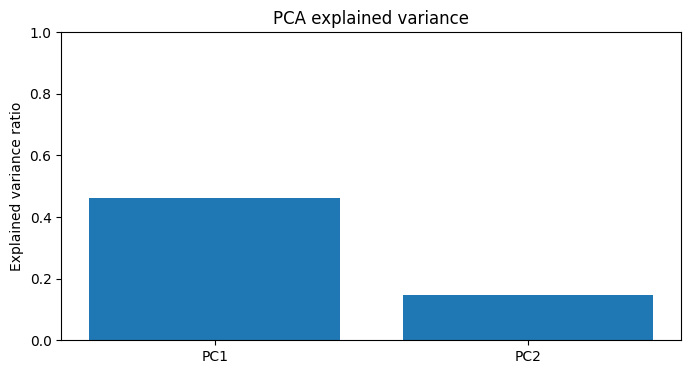

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
pca_df["PC1"] = coords[:, 0]
pca_df["PC2"] = coords[:, 1]

evr = pca.explained_variance_ratio_
print(f"PC1 explained variance: {evr[0]:.1%}")
print(f"PC2 explained variance: {evr[1]:.1%}")
print(f"Combined 2D explained variance: {evr.sum():.1%}")

plt.figure(figsize=(8, 4))
plt.bar(["PC1", "PC2"], evr)
plt.ylabel("Explained variance ratio")
plt.title("PCA explained variance")
plt.ylim(0, 1)
plt.show()

## 7. Plot articles by trend direction

Each point is a client-content observation. If content IDs appear for multiple clients, the same content hash can therefore appear more than once. To keep plots readable on a very large dataset, the plot can use a random sample while all PCA coordinates remain available in `pca_df`.

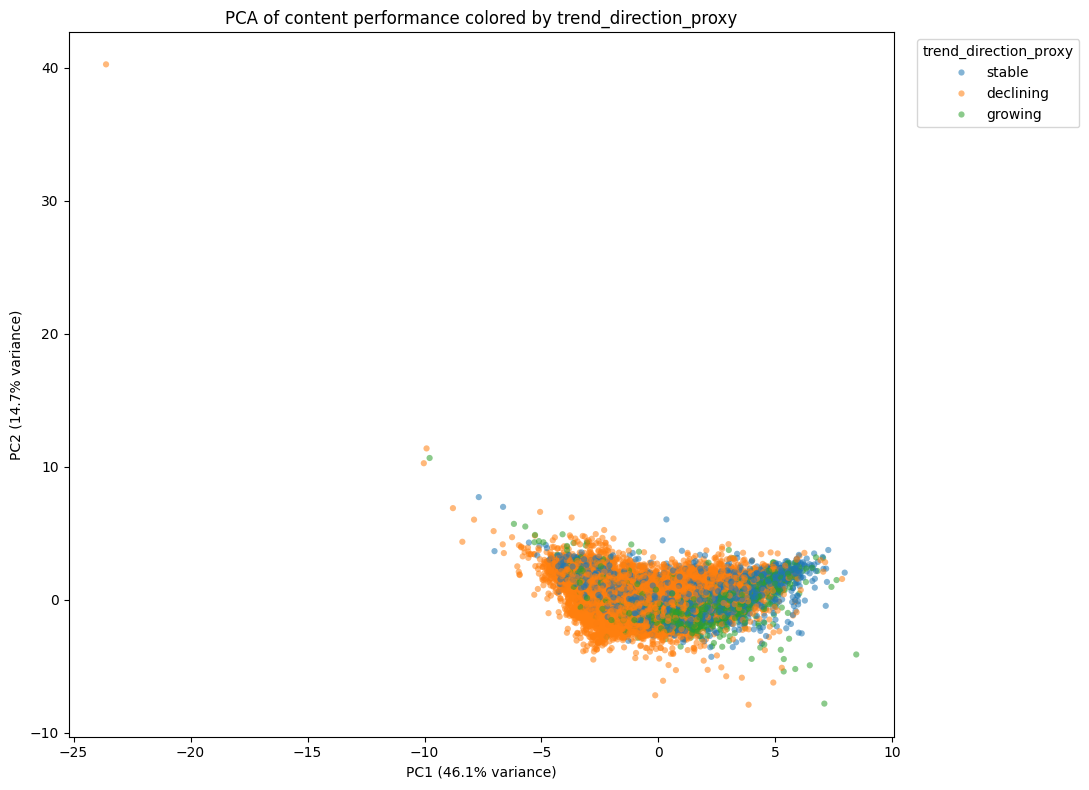

In [9]:
MAX_PLOT_POINTS = 30000  # visualization cap only; PCA above used all prepared rows
if len(pca_df) > MAX_PLOT_POINTS:
    plot_df = pca_df.sample(n=MAX_PLOT_POINTS, random_state=42)
else:
    plot_df = pca_df

plt.figure(figsize=(11, 8))
sns.scatterplot(
    data=plot_df, x="PC1", y="PC2", hue=label_col,
    alpha=0.55, s=20, linewidth=0
)
plt.title(f"PCA of content performance colored by {label_col}")
plt.xlabel(f"PC1 ({evr[0]:.1%} variance)")
plt.ylabel(f"PC2 ({evr[1]:.1%} variance)")
plt.legend(title=label_col, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 8. Quantify whether labels appear separated

We compare average PC coordinates by label and calculate the silhouette score using the labels as groups. This is a descriptive diagnostic, not a predictive evaluation. A silhouette score is only computed when there are at least two labels and fewer labels than observations. Because a source label or proxy can be imbalanced, also inspect class counts and the plot.

In [10]:
label_summary = pca_df.groupby(label_col, dropna=False).agg(
    rows=("PC1", "size"),
    mean_PC1=("PC1", "mean"),
    mean_PC2=("PC2", "mean"),
    median_trend_pct=("trend_pct", "median"),
    median_ctr_last30=("ctr_last30", "median"),
    median_position_change=("position_change", "median")
).sort_values("rows", ascending=False)
display(label_summary)

from sklearn.metrics import silhouette_score
label_values = pca_df[label_col].astype(str)
n_labels = label_values.nunique()
if 2 <= n_labels < len(pca_df):
    # Use a sample for speed when there are many rows.
    if len(pca_df) > 10000:
        sil_idx = pca_df.sample(n=10000, random_state=42).index
        X_sil = pca_df.loc[sil_idx, ["PC1", "PC2"]].to_numpy()
        y_sil = label_values.loc[sil_idx].to_numpy()
    else:
        X_sil = pca_df[["PC1", "PC2"]].to_numpy()
        y_sil = label_values.to_numpy()
    print("Silhouette score in 2D PCA space (descriptive only):", round(silhouette_score(X_sil, y_sil), 4))
else:
    print("Silhouette score skipped: need at least 2 label groups and fewer groups than observations.")

,rows,mean_PC1,mean_PC2,median_trend_pct,median_ctr_last30,median_position_change
trend_direction_proxy,,,,,,
declining,63597,-0.510801,0.032547,-0.606780,0.000000,1.153940
stable,29681,0.599600,0.118066,-0.094915,0.002650,-0.410708
growing,17969,0.817446,-0.310212,0.941725,0.003373,-2.617780


Silhouette score in 2D PCA space (descriptive only): -0.0155


In [11]:
# Inspect PCA component loadings: which original features contribute to PC1 and PC2?
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=["PC1_loading", "PC2_loading"]
)
display(loadings.sort_values("PC1_loading", key=lambda s: s.abs(), ascending=False))

,PC1_loading,PC2_loading
log_clk_last30,0.403885,0.147879
log_clk_prev30,0.403679,0.219600
log_imp_last30,0.369986,0.324996
log_imp_prev30,0.364497,0.397595
pos_volatility_60d,-0.359207,0.111467
pos_last30,-0.329322,0.494424
pos_prev30,-0.302568,0.236337
ctr_prev30,0.207864,-0.200825
position_change,-0.127048,0.476346
ctr_last30,0.125675,-0.293654


In [12]:
# Export the compact PCA result and label summary
OUT_PCA = "flyrank_pca_content_projection.csv"
OUT_LABEL_SUMMARY = "flyrank_pca_trend_label_summary.csv"
pca_df.to_csv(OUT_PCA, index=False)
label_summary.to_csv(OUT_LABEL_SUMMARY)
print("Saved:", OUT_PCA, OUT_LABEL_SUMMARY)

try:
    from google.colab import files as colab_files
    colab_files.download(OUT_PCA)
    colab_files.download(OUT_LABEL_SUMMARY)
except Exception as exc:
    print("Automatic browser downloads unavailable in this environment:", exc)

Saved: flyrank_pca_content_projection.csv flyrank_pca_trend_label_summary.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Interpretation guide

- **Visible separation:** growing/stable/declining labels occupy different regions of the 2D projection. Confirm with class summaries and other diagnostics; visual separation alone is not proof.
- **Overlap:** the chosen performance features may not distinguish the labels cleanly in two dimensions, or the first two PCs may not retain the relevant structure.
- **Explained variance:** low combined variance means the 2D plot is only a limited view of the full feature space.
- **Label provenance:** check the printed `Label source`. A `trend_direction_proxy` is computed from impression change and is not a warehouse ground-truth label.
- **Next step:** compare PCA plots by client or page type, and evaluate whether clusters remain after controlling for client-specific scale.